In [66]:
# Module 1: Imports and shared settings.
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bayesflow as bf

sys.path.insert(0, "/Users/yimingzang/Documents/thesis/benchmark2")

from benchmark.examples.gaussian.analysis import summry_diagnostic as sd
from benchmark.examples.gaussian.analytic.analytic import GaussianAnalytical
from benchmark.examples.gaussian.npe.estimation import MarginalLikelihoodEstimator

RNG = np.random.default_rng(2026)

num_dims = 20
num_obs = 50
mu_prior_std = 1
likelihood_std = 1

m1_prior_mean = 0.0
m2_prior_mean = 5

prior_means = [0,  1,2,2.5, 3, 4, 5,10]
num_datasets = 50
num_logml_samples = 1000 # number of posterior samples

m1_path = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks/m1_s_20d_50n.keras")
m2_path = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks/m2_s_20d_50n_mu5.keras")


In [67]:
from tqdm.auto import tqdm as original_tqdm
import bayesflow.approximators.helpers.samplers as bf_samplers
import bayesflow.approximators.helpers.conditions as bf_conditions

def quiet_tqdm(*args, **kwargs):
    kwargs["disable"] = True
    return original_tqdm(*args, **kwargs)

bf_samplers.tqdm = quiet_tqdm
bf_conditions.tqdm = quiet_tqdm


In [68]:
# Module 2: Define simulators and load both trained networks.
def prior_m1():
    mu = RNG.normal(loc=m1_prior_mean, scale=mu_prior_std, size=num_dims)
    return dict(mu=mu)
def prior_m2():
    mu = RNG.normal(loc=m2_prior_mean, scale=mu_prior_std, size=num_dims)
    return dict(mu=mu)
def likelihood(mu):
    x =RNG.normal(loc=mu, scale=likelihood_std, size=(num_obs, num_dims))
    return dict(x=x)

def make_prior_mean(m):
    return lambda: dict(mu=RNG.normal(loc=m, scale=mu_prior_std, size=num_dims))


sim_m1 = bf.make_simulator([prior_m1, likelihood])
sim_m2 = bf.make_simulator([prior_m2, likelihood])

app1 = sd.load_approximator(m1_path)
app2 = sd.load_approximator(m2_path)


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Reference distribution of summary-space Mahalanobis distance'}, xlabel='Mahalanobis distance $d_M$', ylabel='Density'>)

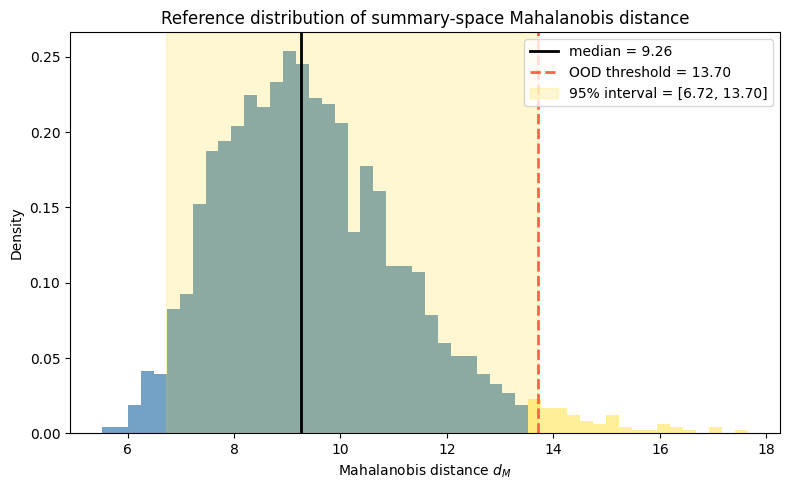

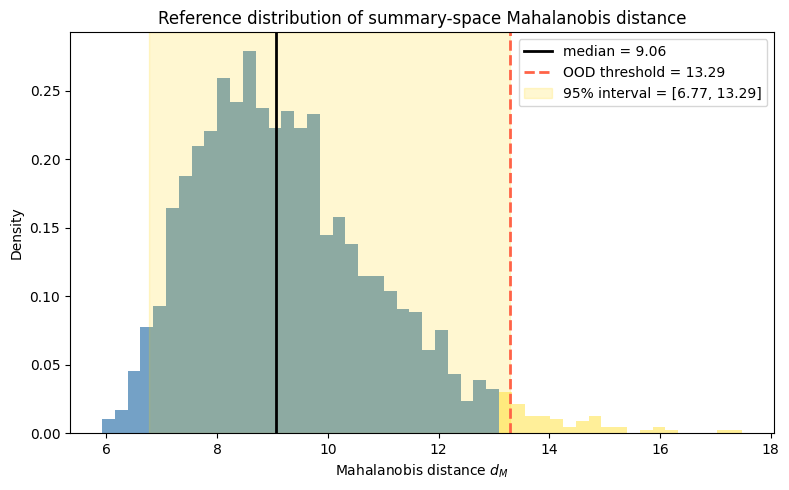

In [69]:
# Module 3: Build each network's own reference d_M distribution.
ref1 = sd.fit_reference(app1, sim_m1, n_ref=2000)
ref2 = sd.fit_reference(app2, sim_m2, n_ref=2000)

sd.plot_reference(ref1)
sd.plot_reference(ref2)


In [70]:
# Module 4: Generate one shared observation set and compute d1, d2, logBF12 error,PMPs error.
rows = []

for pm in prior_means:
    sim_pm = bf.make_simulator([make_prior_mean(pm), likelihood])
    sims = sim_pm.sample(num_datasets)
    x_batch = sims["x"]

    d1 = sd.mahalanobis_from_obs(app1, x_batch, ref1)
    d2 = sd.mahalanobis_from_obs(app2, x_batch, ref2)

    post1 = app1.sample(conditions={"x": x_batch}, num_samples=num_logml_samples)["mu"]
    post2 = app2.sample(conditions={"x": x_batch}, num_samples=num_logml_samples)["mu"]

    for i, x_i in enumerate(x_batch):
        gold1 = GaussianAnalytical(x_i, m1_prior_mean, mu_prior_std, num_dims, num_obs, num_logml_samples, likelihood_std, RNG).log_marginal_analytical()
        gold2 = GaussianAnalytical(x_i, m2_prior_mean, mu_prior_std, num_dims, num_obs, num_logml_samples, likelihood_std, RNG).log_marginal_analytical()

        npe1 = MarginalLikelihoodEstimator(app1, post1[i], x_i, m1_prior_mean, mu_prior_std, num_dims, likelihood_std, rng=RNG).log_marginal_npe()
        npe2 = MarginalLikelihoodEstimator(app2, post2[i], x_i, m2_prior_mean, mu_prior_std, num_dims, likelihood_std, rng=RNG).log_marginal_npe()

        gold_bf12 = gold1 - gold2
        npe_bf12 = npe1 - npe2


        rows.append(
            {
                "prior_mean": pm,
                "id": i,
                "d1": d1[i],
                "d2": d2[i],
                "d_max": max(d1[i], d2[i]),
                "d_min": min(d1[i], d2[i]),
                "d_mean": 0.5 * (d1[i] + d2[i]),
                "d_diff": d1[i] - d2[i],
                "gold_logBF12": gold_bf12,
                "npe_logBF12": npe_bf12,
                "logBF12_error": npe_bf12 - gold_bf12,
                "abs_logBF12_error": abs(npe_bf12 - gold_bf12),
                "ood_m1": d1[i] > ref1["threshold"],
                "ood_m2": d2[i] > ref2["threshold"],
                "ood_any": (d1[i] > ref1["threshold"]) or (d2[i] > ref2["threshold"]),
            }
        )

bf12_df = pd.DataFrame(rows)
display(bf12_df.head())


,prior_mean,id,d1,d2,d_max,d_min,d_mean,d_diff,gold_logBF12,npe_logBF12,logBF12_error,abs_logBF12_error,ood_m1,ood_m2,ood_any
0,0.0,0,11.123100,70.344215,70.344215,11.123100,40.733657,-59.221115,290.898304,1458.021882,1167.123577,1167.123577,False,True,True
1,0.0,1,10.218566,64.454418,64.454418,10.218566,37.336492,-54.235852,233.132609,930.569800,697.437191,697.437191,False,True,True
2,0.0,2,7.763216,65.955513,65.955513,7.763216,36.859365,-58.192297,233.229735,880.292041,647.062306,647.062306,False,True,True
3,0.0,3,9.393213,73.893436,73.893436,9.393213,41.643325,-64.500223,259.842443,1405.976390,1146.133947,1146.133947,False,True,True
4,0.0,4,8.265804,75.946351,75.946351,8.265804,42.106078,-67.680547,300.703392,1328.717595,1028.014203,1028.014203,False,True,True


In [71]:
# Module 5: Summarize by generating prior mean.
bf12_summary = (
    bf12_df.groupby("prior_mean")
    .agg(
        median_d_max=("d_diff", "median"), # the median of the max d_M across the two models
        q025_d_max=("d_diff", lambda x: np.percentile(x, 2.5)),
        q975_d_max=("d_diff", lambda x: np.percentile(x, 97.5)),
        median_d_min=("d_min", "median"), # the median of the min d_M across the two models
        ood_any_rate=("ood_any", "mean"), # the rate of being OOD by at least one model
        median_logBF12_error=("logBF12_error", "median"),
        q025_logBF12_error=("logBF12_error", lambda x: np.percentile(x, 2.5)),
        q975_logBF12_error=("logBF12_error", lambda x: np.percentile(x, 97.5)),
    )
    .reset_index()
)

display(bf12_summary)


,prior_mean,median_d_max,q025_d_max,q975_d_max,median_d_min,ood_any_rate,median_logBF12_error,q025_logBF12_error,q975_logBF12_error
0,0.0,-58.136818,-66.168292,-49.853101,9.754490,1.0,761.689090,426.680777,1183.372524
1,1.0,-41.786471,-51.335520,-31.617298,15.140724,1.0,278.289704,100.489136,690.741471
2,2.0,-16.737329,-24.696763,-4.651947,26.318439,1.0,51.248746,2.125565,118.044938
3,2.5,-4.996371,-20.329884,12.732162,31.094915,1.0,1.851739,-43.007591,67.478200
4,3.0,11.660541,-4.060660,24.857093,26.903025,1.0,-49.287312,-155.174667,-2.435864
5,4.0,36.159986,19.730247,47.881309,14.287501,1.0,-299.658102,-573.794883,-105.730103
6,5.0,51.979491,41.191583,65.085209,8.923735,1.0,-1034.883530,-1499.760358,-642.871732
7,10.0,51.509777,32.245558,70.920391,55.846324,1.0,-22147.301908,-25394.608971,-17916.071138


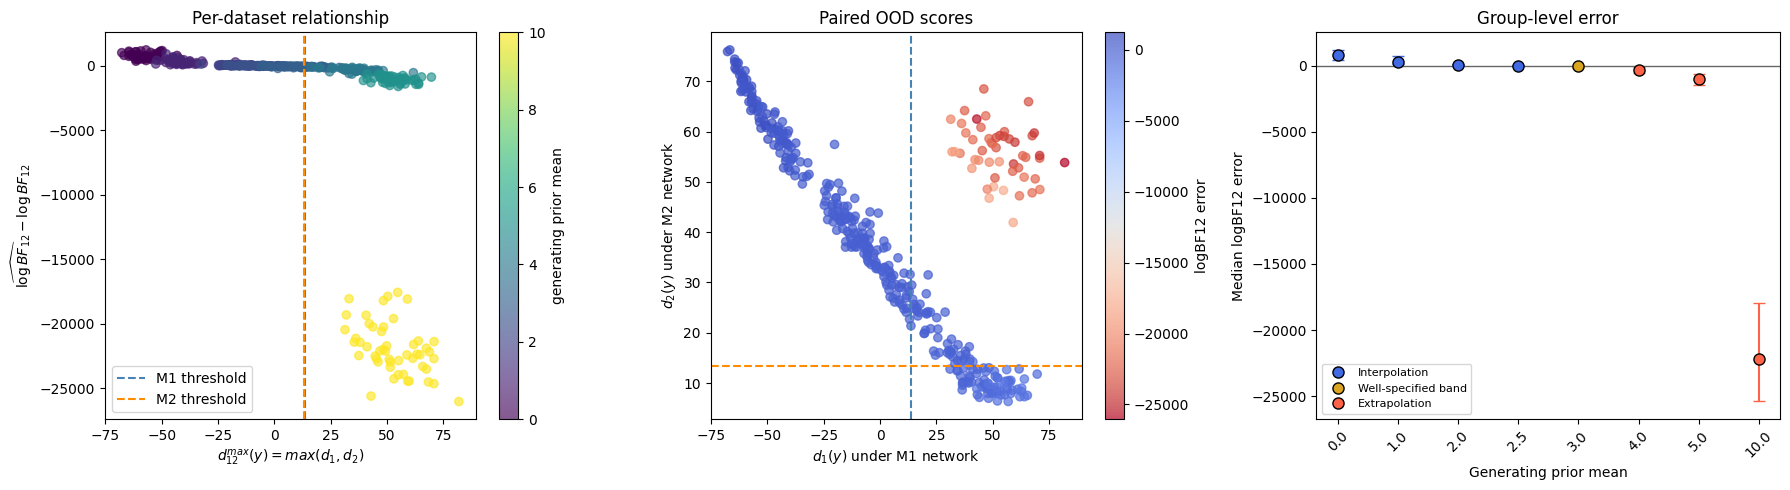

In [72]:
# Module 6: Plot paired OOD scores vs absolute logBF12 error.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc = axes[0].scatter(bf12_df["d_diff"], bf12_df["logBF12_error"], c=bf12_df["prior_mean"], cmap="viridis", alpha=0.65)
axes[0].axvline(ref1["threshold"], color="steelblue", ls="--", label="M1 threshold")
axes[0].axvline(ref2["threshold"], color="darkorange", ls="--", label="M2 threshold")
axes[0].set_xlabel(r"$d_{12}^{max}(y)=max(d_1,d_2)$")
axes[0].set_ylabel(r"$\widehat{\log BF}_{12} - \log BF_{12}$")
axes[0].set_title("Per-dataset relationship")
axes[0].legend()
fig.colorbar(sc, ax=axes[0], label="generating prior mean")

er=axes[1].scatter(bf12_df["d_diff"], bf12_df["d2"], c=bf12_df["logBF12_error"], cmap="coolwarm_r", alpha=0.70)
axes[1].axvline(ref1["threshold"], color="steelblue", ls="--")
axes[1].axhline(ref2["threshold"], color="darkorange", ls="--")
axes[1].set_xlabel(r"$d_1(y)$ under M1 network")
axes[1].set_ylabel(r"$d_2(y)$ under M2 network")
axes[1].set_title("Paired OOD scores")
fig.colorbar(er, ax=axes[1], label="logBF12 error")

# Group-level error colored by OOD region.
x = np.arange(len(bf12_summary))

region_colors = []
for d in bf12_summary["median_d_max"]:
    if d < min(ref1["median"], ref2["median"]):
        region_colors.append("royalblue")   # interpolation
    elif d <= max(ref1["threshold"], ref2["threshold"]):
        region_colors.append("goldenrod")   # well-specified band
    else:
        region_colors.append("tomato")      # extrapolation (at least one model)

axes[2].axhline(0, color="black", lw=1, alpha=0.6)

for i, row in bf12_summary.iterrows():
    axes[2].errorbar(
        i,
        row["median_logBF12_error"],
        yerr=[
            [row["median_logBF12_error"] - row["q025_logBF12_error"]],
            [row["q975_logBF12_error"] - row["median_logBF12_error"]],
        ],
        fmt="o",
        ms=8,
        capsize=4,
        color=region_colors[i],
        markeredgecolor="black",
    )

axes[2].set_xticks(x)
axes[2].set_xticklabels([str(v) for v in bf12_summary["prior_mean"]], rotation=45)
axes[2].set_xlabel("Generating prior mean")
axes[2].set_ylabel("Median logBF12 error")
axes[2].set_title("Group-level error")

from matplotlib.lines import Line2D
axes[2].legend(
    handles=[
        Line2D([0], [0], marker="o", color="w", label="Interpolation", markerfacecolor="royalblue", markeredgecolor="black", markersize=8),
        Line2D([0], [0], marker="o", color="w", label="Well-specified band", markerfacecolor="goldenrod", markeredgecolor="black", markersize=8),
        Line2D([0], [0], marker="o", color="w", label="Extrapolation", markerfacecolor="tomato", markeredgecolor="black", markersize=8),
    ],
    fontsize=8,
)
plt.tight_layout()
plt.show()


In [73]:
# Module 7: Convert logBF12 to two-model PMP using the project softmax.
from benchmark.examples.gaussian.direct.calculator import softmax_stable

bf12_df["gold_pmp_m1"] = [softmax_stable(np.array([v, 0.0]))[0] for v in bf12_df["gold_logBF12"]]
bf12_df["npe_pmp_m1"] = [softmax_stable(np.array([v, 0.0]))[0] for v in bf12_df["npe_logBF12"]]
bf12_df["pmp_m1_error"] = bf12_df["npe_pmp_m1"] - bf12_df["gold_pmp_m1"]
bf12_df["abs_pmp_m1_error"] = bf12_df["pmp_m1_error"].abs()

pmp12_summary = (
    bf12_df.groupby("prior_mean")
    .agg(
        median_d_max=("d_diff", "median"),
        q025_d_max=("d_diff", lambda x: np.percentile(x, 2.5)),
        q975_d_max=("d_diff", lambda x: np.percentile(x, 97.5)),
        ood_any_rate=("ood_any", "mean"),
        median_pmp_m1_error=("pmp_m1_error", "median"),
        q025_pmp_m1_error=("pmp_m1_error", lambda x: np.percentile(x, 2.5)),
        q975_pmp_m1_error=("pmp_m1_error", lambda x: np.percentile(x, 97.5)),
        median_abs_pmp_m1_error=("abs_pmp_m1_error", "median"),
    )
    .reset_index()
)

display(pmp12_summary)


,prior_mean,median_d_max,q025_d_max,q975_d_max,ood_any_rate,median_pmp_m1_error,q025_pmp_m1_error,q975_pmp_m1_error,median_abs_pmp_m1_error
0,0.0,-58.136818,-66.168292,-49.853101,1.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,1.0,-41.786471,-51.335520,-31.617298,1.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,2.0,-16.737329,-24.696763,-4.651947,1.0,0.000000e+00,0.000000e+00,2.570442e-02,0.000000e+00
3,2.5,-4.996371,-20.329884,12.732162,1.0,0.000000e+00,-1.554236e-01,3.080593e-01,8.118607e-06
4,3.0,11.660541,-4.060660,24.857093,1.0,-1.790133e-24,-2.949605e-06,-3.598448e-37,2.847851e-24
5,4.0,36.159986,19.730247,47.881309,1.0,-7.213143e-68,-1.186429e-40,-4.412595e-79,7.213143e-68
6,5.0,51.979491,41.191583,65.085209,1.0,-1.542665e-104,-6.402697e-92,-6.121283e-120,1.542665e-104
7,10.0,51.509777,32.245558,70.920391,1.0,-8.300303e-321,-3.223878e-301,0.000000e+00,8.300303e-321


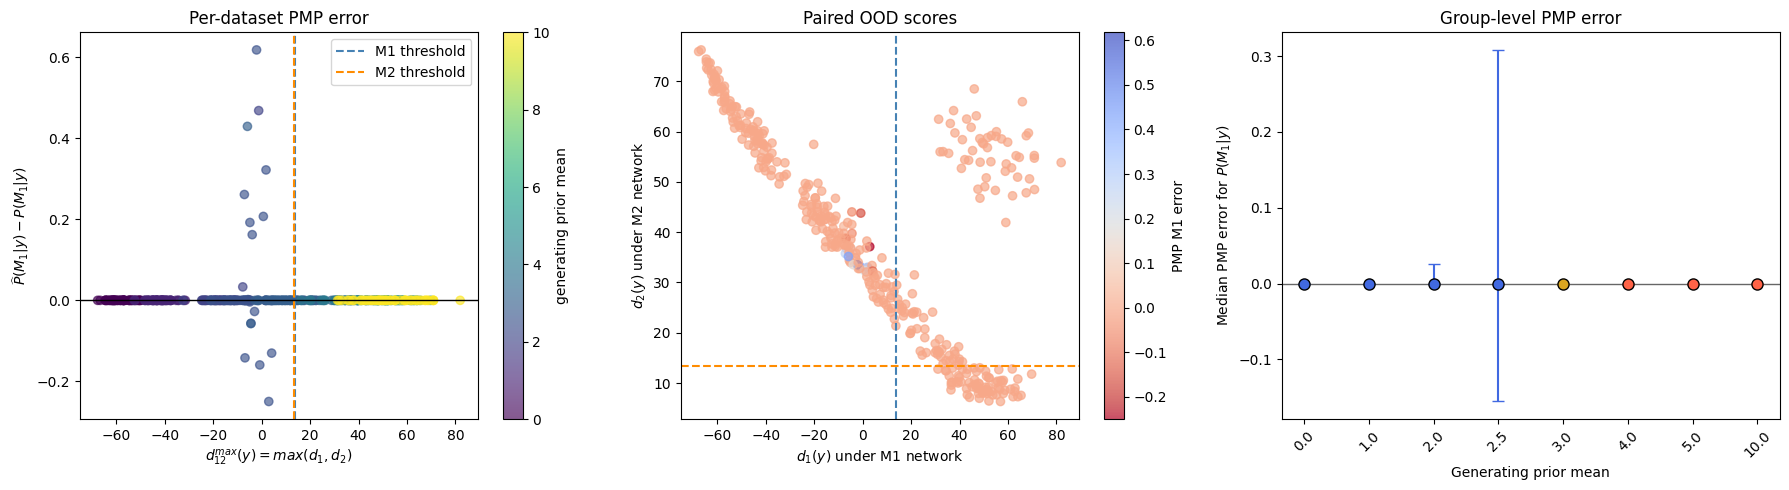

In [77]:
# Module 8: Plot paired OOD scores vs PMP error for P(M1 | y).
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc = axes[0].scatter(bf12_df["d_diff"], bf12_df["pmp_m1_error"], c=bf12_df["prior_mean"], cmap="viridis", alpha=0.65)
axes[0].axvline(ref1["threshold"], color="steelblue", ls="--", label="M1 threshold")
axes[0].axvline(ref2["threshold"], color="darkorange", ls="--", label="M2 threshold")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_xlabel(r"$d_{12}^{max}(y)=max(d_1,d_2)$")
axes[0].set_ylabel(r"$\widehat{P}(M_1|y)-P(M_1|y)$")
axes[0].set_title("Per-dataset PMP error")
axes[0].legend()
fig.colorbar(sc, ax=axes[0], label="generating prior mean")

er = axes[1].scatter(bf12_df["d_diff"], bf12_df["d2"], c=bf12_df["pmp_m1_error"], cmap="coolwarm_r", alpha=0.70)
axes[1].axvline(ref1["threshold"], color="steelblue", ls="--")
axes[1].axhline(ref2["threshold"], color="darkorange", ls="--")
axes[1].set_xlabel(r"$d_1(y)$ under M1 network")
axes[1].set_ylabel(r"$d_2(y)$ under M2 network")
axes[1].set_title("Paired OOD scores")
fig.colorbar(er, ax=axes[1], label="PMP M1 error")

region_colors = []
for d in pmp12_summary["median_d_max"]:
    if d < min(ref1["median"], ref2["median"]):
        region_colors.append("royalblue")
    elif d <= max(ref1["threshold"], ref2["threshold"]):
        region_colors.append("goldenrod")
    else:
        region_colors.append("tomato")

x = np.arange(len(pmp12_summary))
axes[2].axhline(0, color="black", lw=1, alpha=0.6)
for i, row in pmp12_summary.iterrows():
    axes[2].errorbar(
        i,
        row["median_pmp_m1_error"],
        yerr=[
            [row["median_pmp_m1_error"] - row["q025_pmp_m1_error"]],
            [row["q975_pmp_m1_error"] - row["median_pmp_m1_error"]],
        ],
        fmt="o",
        ms=8,
        capsize=4,
        color=region_colors[i],
        markeredgecolor="black",
    )

axes[2].set_xticks(x)
axes[2].set_xticklabels([str(v) for v in pmp12_summary["prior_mean"]], rotation=45)
axes[2].set_xlabel("Generating prior mean")
axes[2].set_ylabel(r"Median PMP error for $P(M_1|y)$")
axes[2].set_title("Group-level PMP error")

plt.tight_layout()
plt.show()


In [75]:
prior_mean_errpmp = (
    bf12_df
    .groupby("prior_mean", sort=False)["pmp_m1_error"]
    .agg(
        median_pmp_m1_error="median",
        q025_pmp_m1_error=lambda x: np.percentile(x, 2.5),
        q975_pmp_m1_error=lambda x: np.percentile(x, 97.5),
    )
    .reset_index()
)

prior_mean_errpmp["median_pmp_m1_error [95% CI]"] = prior_mean_errpmp.apply(
    lambda r: f"{r['median_pmp_m1_error']:.5f} [{r['q025_pmp_m1_error']:.5f}, {r['q975_pmp_m1_error']:.5f}]",
    axis=1,
)

display(prior_mean_errpmp.round(5))

,prior_mean,median_pmp_m1_error,q025_pmp_m1_error,q975_pmp_m1_error,median_pmp_m1_error [95% CI]
0,0.0,0.0,0.00000,0.00000,"0.00000 [0.00000, 0.00000]"
1,1.0,0.0,0.00000,0.00000,"0.00000 [0.00000, 0.00000]"
2,2.0,0.0,0.00000,0.02570,"0.00000 [0.00000, 0.02570]"
3,2.5,0.0,-0.15542,0.30806,"0.00000 [-0.15542, 0.30806]"
4,3.0,-0.0,-0.00000,-0.00000,"-0.00000 [-0.00000, -0.00000]"
5,4.0,-0.0,-0.00000,-0.00000,"-0.00000 [-0.00000, -0.00000]"
6,5.0,-0.0,-0.00000,-0.00000,"-0.00000 [-0.00000, -0.00000]"
7,10.0,-0.0,-0.00000,0.00000,"-0.00000 [-0.00000, 0.00000]"


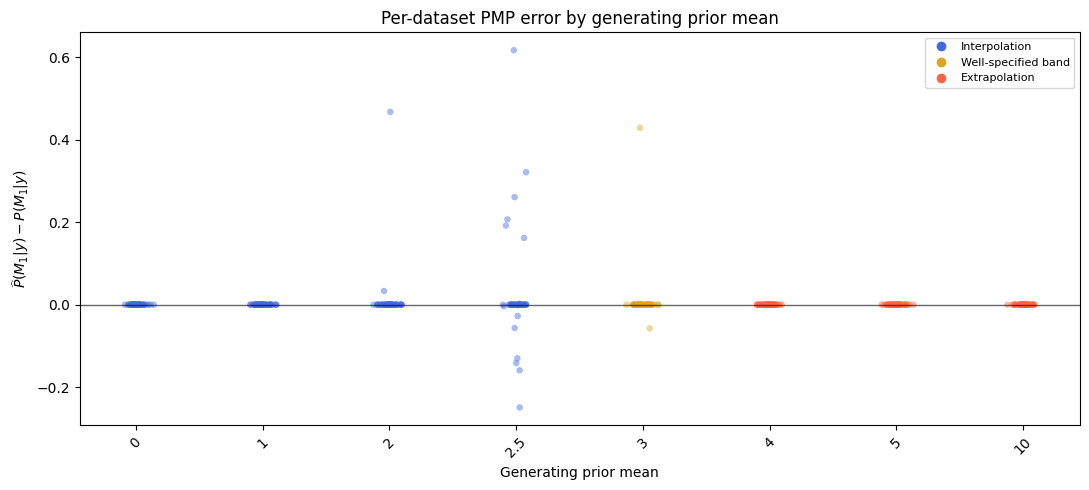

In [76]:
# Plot per-dataset PMP error by prior mean, colored by OOD region.
x = np.arange(len(prior_means))

region_colors = []
for d in pmp12_summary["median_d_max"]:
    if d < min(ref1["median"], ref2["median"]):
        region_colors.append("royalblue")
    elif d <= max(ref1["threshold"], ref2["threshold"]):
        region_colors.append("goldenrod")
    else:
        region_colors.append("tomato")

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(0, color="black", lw=1, alpha=0.6)

for i, pm in enumerate(prior_means):
    vals = bf12_df.loc[bf12_df["prior_mean"] == pm, "pmp_m1_error"].to_numpy()
    jitter = np.random.default_rng(2026 + i).normal(0, 0.045, size=len(vals))
    ax.scatter(
        np.full(len(vals), i) + jitter,
        vals,
        s=22,
        alpha=0.45,
        color=region_colors[i],
        edgecolors="none",
    )

ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in prior_means], rotation=45)
ax.set_xlabel("Generating prior mean")
ax.set_ylabel(r"$\widehat{P}(M_1|y)-P(M_1|y)$")
ax.set_title("Per-dataset PMP error by generating prior mean")

from matplotlib.lines import Line2D
ax.legend(
    handles=[
        Line2D([0], [0], marker="o", color="w", label="Interpolation", markerfacecolor="royalblue", markersize=8),
        Line2D([0], [0], marker="o", color="w", label="Well-specified band", markerfacecolor="goldenrod", markersize=8),
        Line2D([0], [0], marker="o", color="w", label="Extrapolation", markerfacecolor="tomato", markersize=8),
    ],
    fontsize=8,
)

plt.tight_layout()
plt.show()